# Simulação de membrana elástica:
### Estudo das vibrações em uma membrana elástica circular, utilizando discretização numérica do domínio e o cálculo de autovalores e de autovetores.
#### Disciplina: SME0602 — Motores Numéricos para Simulação em Engenharia
#### Professor: Roberto F. Ausas
#### Grupo 3: 
* #### Beatriz Cosimatti
* #### Cecilia Queiroz
* #### Gabriel Zago
* #### Matheus Buzzon
* #### Pedro Vale
* #### Victor Silva


In [2]:
# Importações!!!
import importlib

import mechanic
importlib.reload(mechanic)
import env
importlib.reload(env)
config = env.CONFIG_M

##### O sistema mecânico foi implementado a partir de uma classe base capaz de resolver o problema dos modos de vibração de uma membrana elástica com oscilações livres via o cálculo dos autovalores e autovetores da matriz de rigidez K, quando a matriz diagonal associada é a matriz de masssas M.

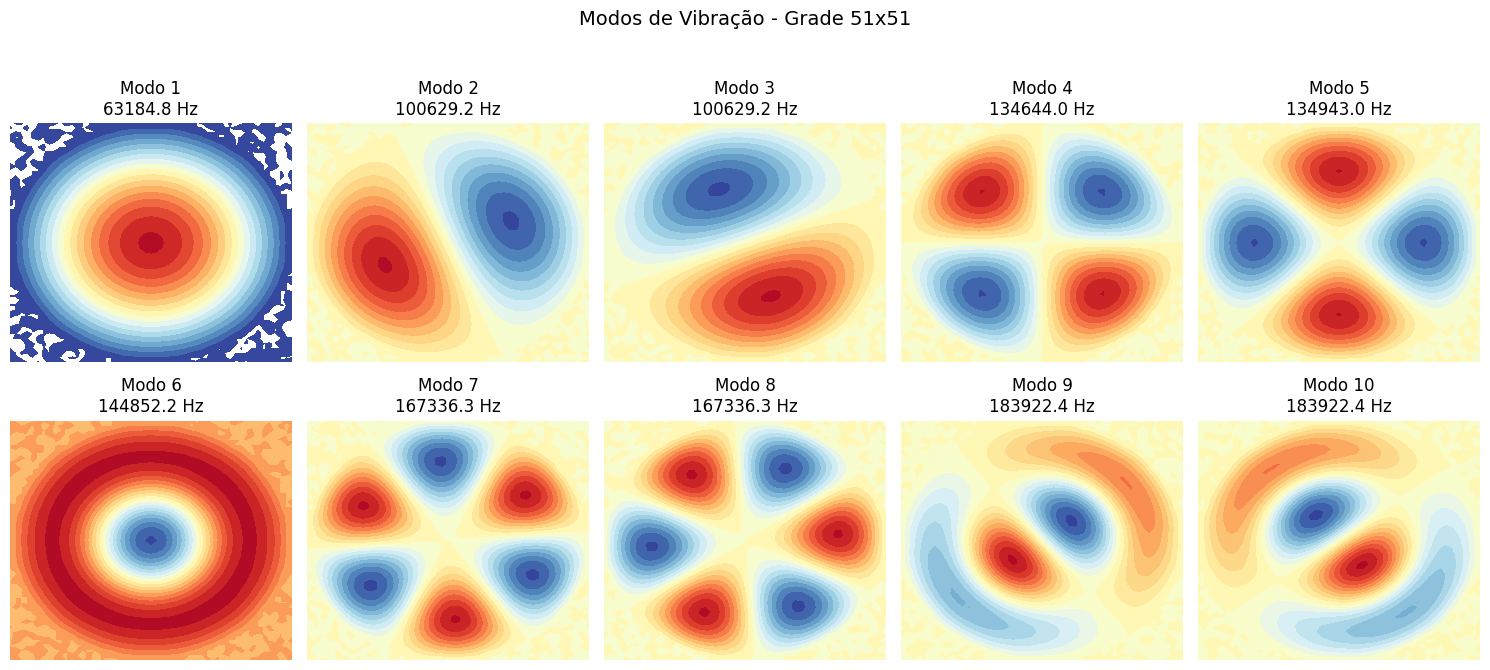

In [3]:
membrana_elastica =  mechanic.Mechanic(config)
membrana_elastica.run(print_info=False, plot=True)

___
##### Para analisar o efeito da discretização do sistema, resolveu-se o caso base descrito acima para as diferentes discretizações de N: (21 , 21), (41, 41), (61, 61), (81 , 81), (101 , 101)

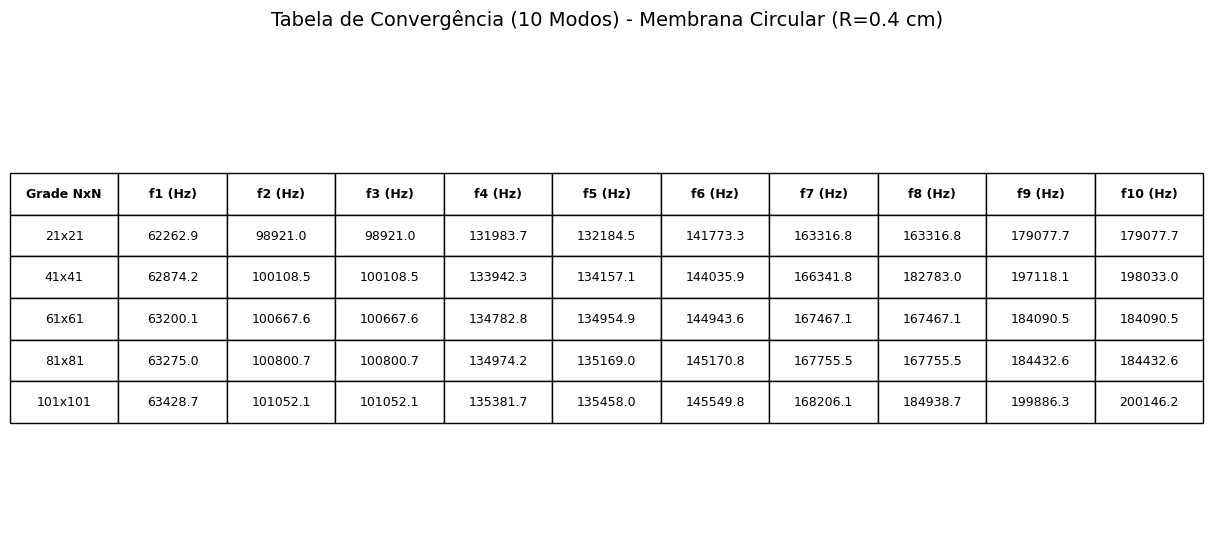

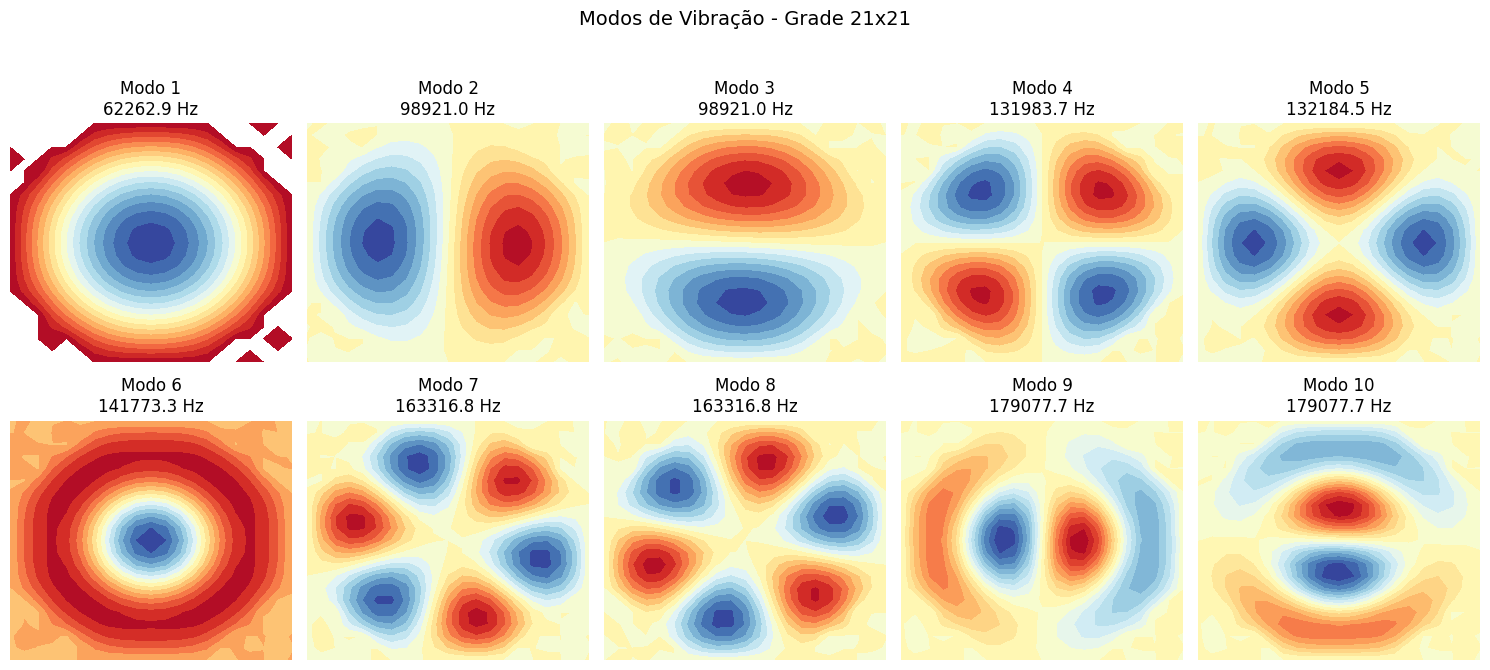

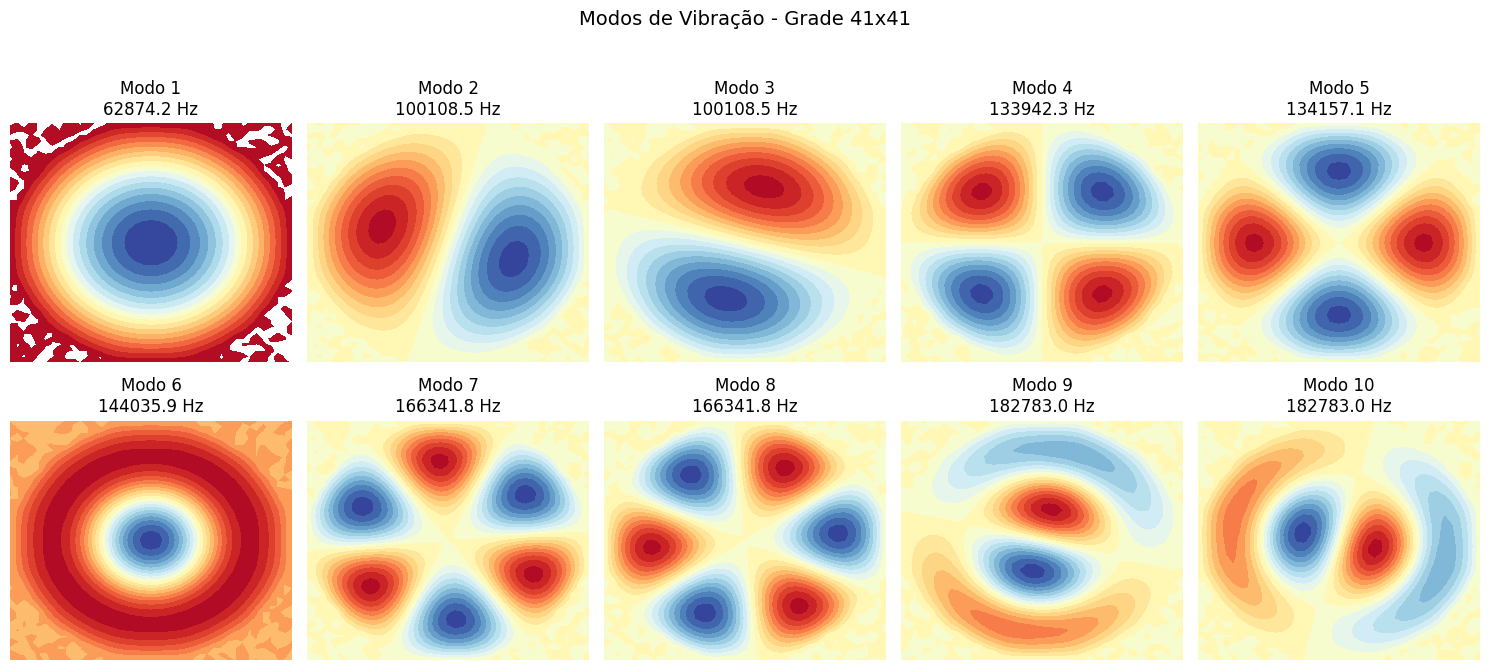

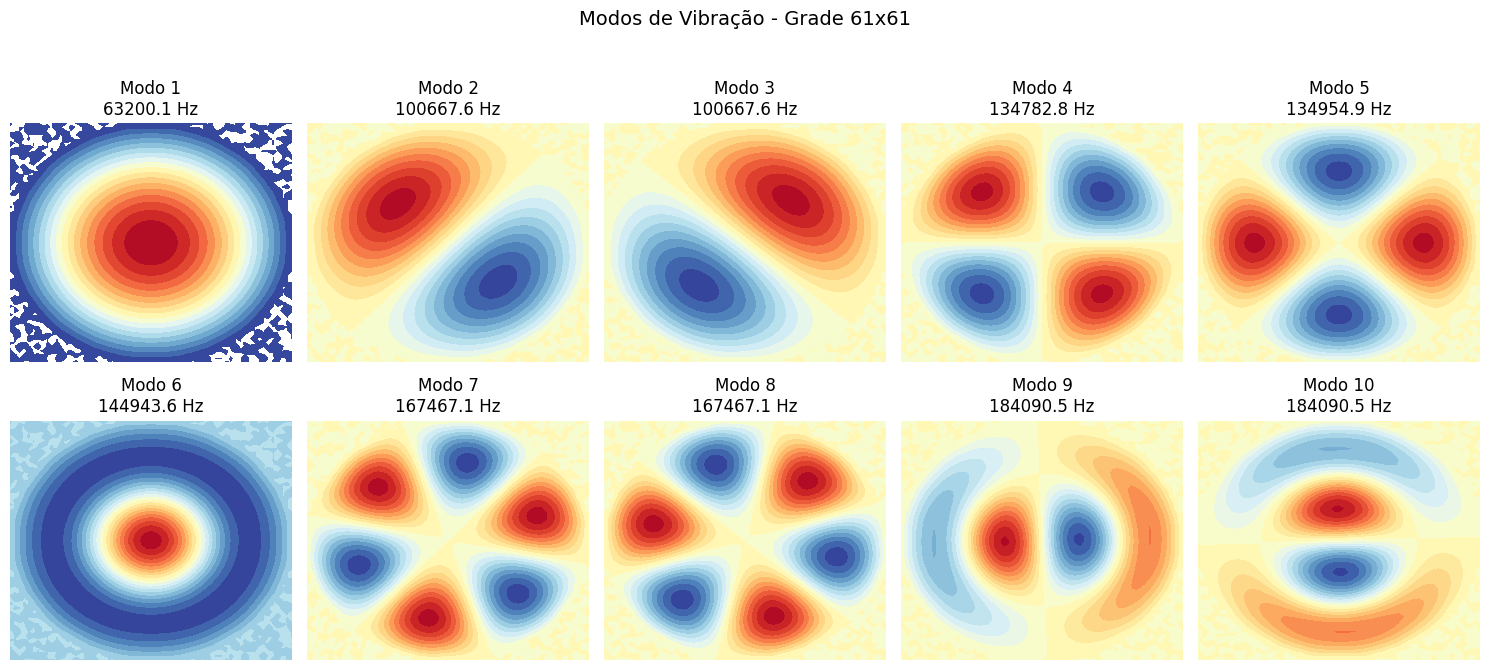

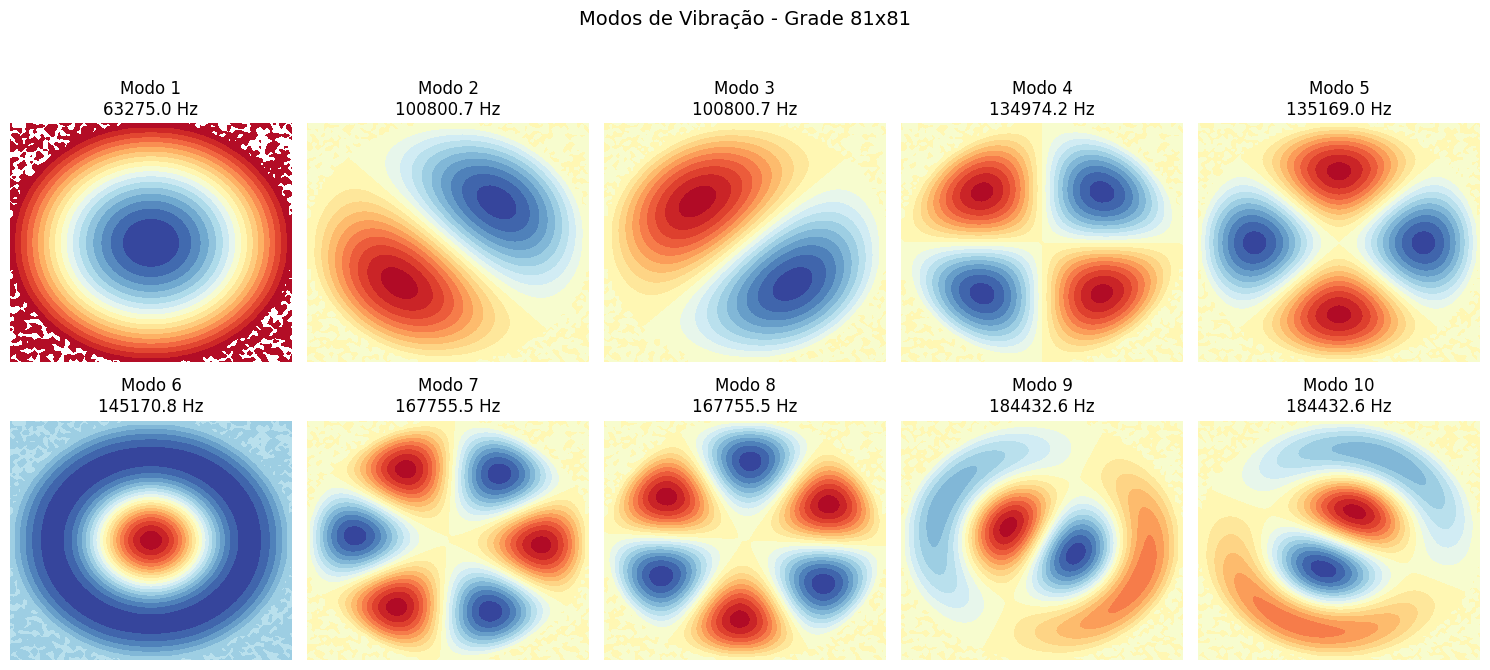

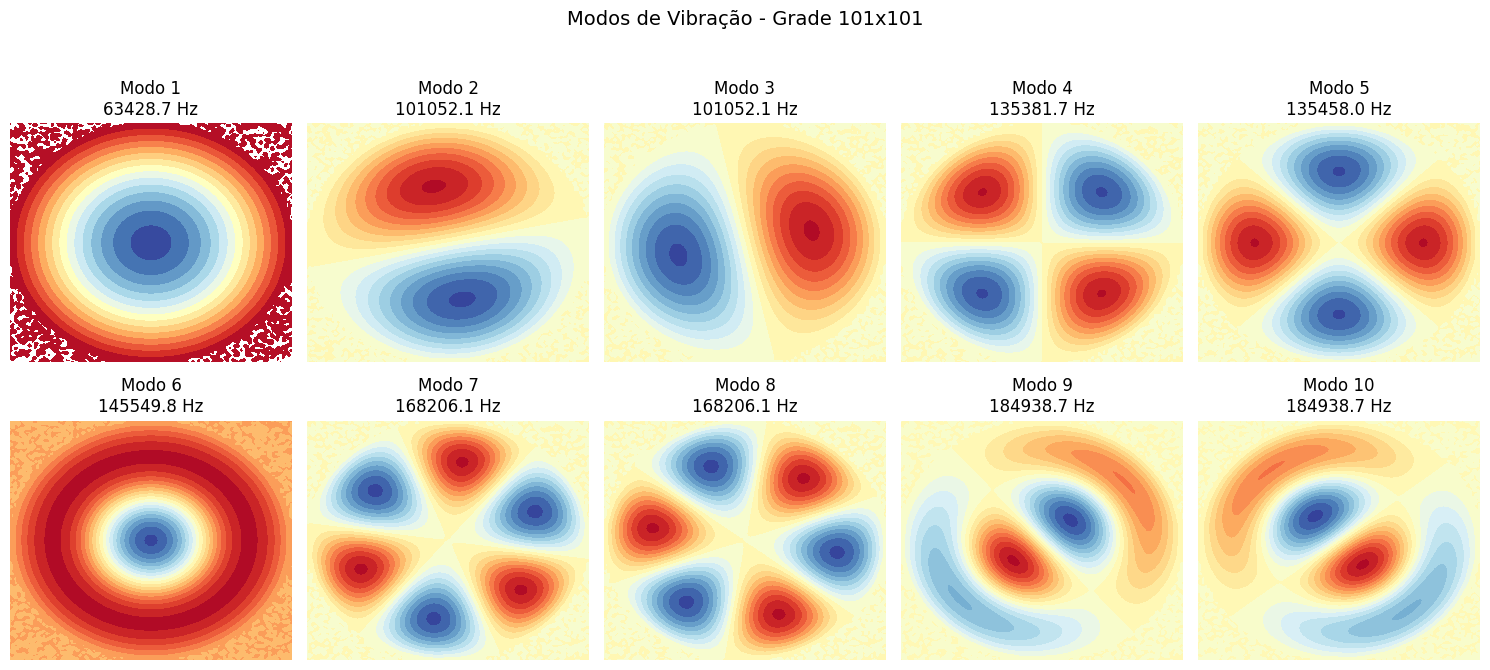

In [4]:
analise_discretizacao = mechanic.Mechanic_P2(config)

# Gera a tabela
analise_discretizacao.plot_convergence_table_image(config["MULTI_N"])

# Plota os modos sequencialmente
analise_discretizacao.plot_modes(config["MULTI_N"])

___
##### Considerando os casos acima onde há oscilações livres, a evolução do sistema:

$$ Mw'' + Kw = 0 $$

##### onde se conhece o deslocamento inicial w(0) = U, e a velocidade inicial w`(0) = V, é:

$$ \sum_{k=1}^{n} \Phi^{(k)} c_k sin(\omega_{k}t + \Phi_{k}) $$

##### Para encontrar os coeficientes $ c_i $ e $ \Phi_{i} $, foram feitos cálculos que encontram as fórmulas analíticas (disposto no arquivo Exo_teorico.pdf)

___
##### Considerando agora o caso onde há oscilações forçadas, obtevemos a representação do seguinte termo forçante f na base de autovetores generalizados $ M \Phi^{(k)} $

$$ \hat{f}(\hat{x}, \hat{y}, \hat{t}) = [(\hat{x} - 0.5)^2 + (\hat{y} - 0.5)^2]cos(\hat{\omega_*}\hat{t}) $$

In [5]:
analise_oscilacao_forcada = mechanic.Mechanic_P4(config)
analise_oscilacao_forcada.run(print_info = True)

RESULTADO DA PROJEÇÃO MODAL:
    Modo 1 (63184.75 Hz): Coeficiente 0: 63184.753544
    Modo 2 (100629.17 Hz): Coeficiente 1: 100629.169247
    Modo 3 (100629.17 Hz): Coeficiente 2: 100629.169247
    Modo 4 (134644.03 Hz): Coeficiente 3: 134644.032897
    Modo 5 (134943.00 Hz): Coeficiente 4: 134943.000460
    Modo 6 (144852.15 Hz): Coeficiente 5: 144852.152533
    Modo 7 (167336.26 Hz): Coeficiente 6: 167336.258567
    Modo 8 (167336.26 Hz): Coeficiente 7: 167336.258567
    Modo 9 (183922.36 Hz): Coeficiente 8: 183922.355064
    Modo 10 (183922.36 Hz): Coeficiente 9: 183922.355064


REPRESENTAÇÃO DO TERMO FORÇANTE NA BASE MODAL:
    Termo 1: (-30.260556) * Phi_1 * cos(omega_s * t)
    Termo 2: (-23.489615) * Phi_2 * cos(omega_s * t)
    Termo 3: (1.547680) * Phi_3 * cos(omega_s * t)
    Termo 4: (-0.000000) * Phi_4 * cos(omega_s * t)
    Termo 5: (0.000000) * Phi_5 * cos(omega_s * t)
    Termo 6: (22.398433) * Phi_6 * cos(omega_s * t)
    Termo 7: (0.007738) * Phi_7 * cos(omega_s * t)


##### Por último, desenvolvemos um método capaz de plotar a função que retorna a energia elástica média para diferentes valores de $ \omega_{*} $

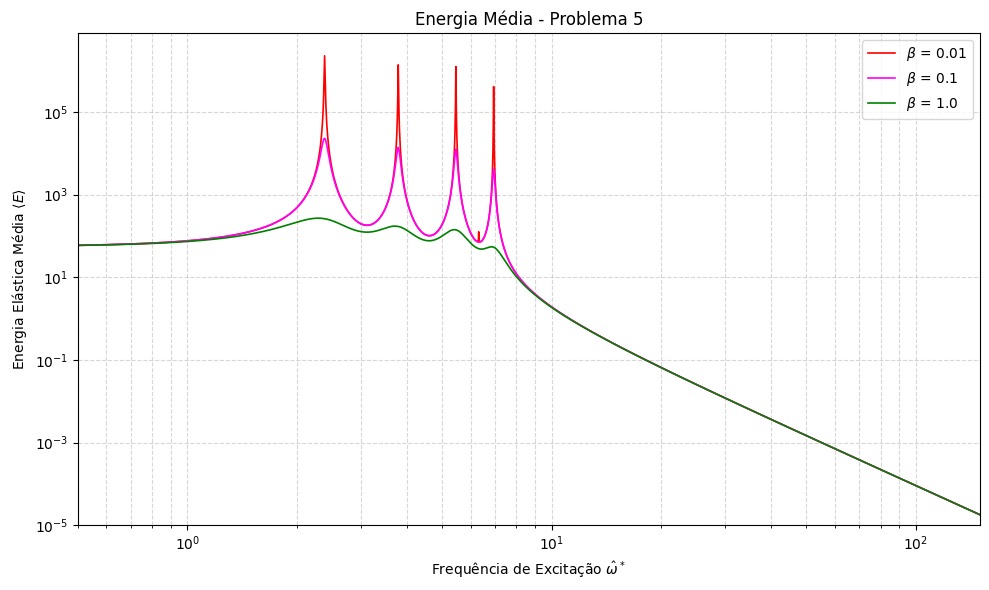

In [6]:
analise_oscilacao_forcada.P5_plot_average_elastic_energy()